### Estudo das respostas de outros modelos de llms - Antropic SLR1

Vamos simular as variabilidade das respostas das llms, olhando para as soluções da Antropic

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import anthropic
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
### style de execução
tqdm.pandas()

### variaveis de ambiente e conexões

In [3]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

True

In [4]:
for key in os.environ.keys():
    print(f'{key}')

HOSTNAME
HOME
GPG_KEY
PYTHON_SHA256
PATH
LANG
SHELL
PYTHON_VERSION
PWD
VSCODE_CWD
VSCODE_NLS_CONFIG
VSCODE_HANDLES_SIGPIPE
VSCODE_ESM_ENTRYPOINT
VSCODE_HANDLES_UNCAUGHT_ERRORS
REMOTE_CONTAINERS_IPC
REMOTE_CONTAINERS_SOCKETS
SHLVL
_
REMOTE_CONTAINERS
BROWSER
ELECTRON_RUN_AS_NODE
VSCODE_IPC_HOOK_CLI
APPLICATION_INSIGHTS_NO_STATSBEAT
VSCODE_L10N_BUNDLE_LOCATION
PYDEVD_IPYTHON_COMPATIBLE_DEBUGGING
PYTHONUNBUFFERED
PYTHONIOENCODING
PYTHON_FROZEN_MODULES
PYDEVD_USE_FRAME_EVAL
TERM
CLICOLOR
FORCE_COLOR
CLICOLOR_FORCE
PAGER
GIT_PAGER
MPLBACKEND
KMP_DUPLICATE_LIB_OK
KMP_INIT_AT_FORK
OPENAI_API_KEY_GOV_ANALITICA
GOOGLE_API_KEY_LLMS_PROF_DANILO
ANTROPIC_API_KEY_LLMS
GOOGLE_CLOUD_PROJECT
GOOGLE_CLOUD_REGION


In [5]:

# Configurar a chave de API
client = anthropic.Anthropic(api_key=os.getenv("ANTROPIC_API_KEY_LLMS"))

In [6]:

# Define os parâmetros da solicitação usando a API de mensagens (v2)
response = client.messages.create(
    model="claude-3-5-haiku-20241022",
    max_tokens=10,
    messages=[
        {"role": "user", "content": "Olá, Claude! Qual a capital do Brasil?"}
    ]
)

# Exibe a resposta gerada pelo mode
print(response.content[0].text)

A capital do Brasil é Brasília, local


# LLMs da Antropic
-----

### Leitura dos arquivos

In [7]:
df_slr1 = pd.read_excel("/data/codigos/dados/titulo_resumo_palavras_slr1_v2.xlsx",engine='openpyxl')
df_slr1.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado
2,slr1_3,Machine learning\n based cognitive skills cal...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado


In [8]:
df_slr1 = df_slr1.replace({r'_x000D_|\n': ''}, regex=True)

In [9]:
df_slr1.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado
2,slr1_3,Machine learning based cognitive skills calcu...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado
3,slr1_4,Human Factors Engineering in Interactive Urba...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado
4,slr1_5,Empirical comparisons for combining balancing...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado


#### Limpeza dos casos em que não conseguimos extrair as informações


In [10]:
# aqui precisamos, para reproduzir o artigo que ambos os campos tenho informação
df_slr1_clear = df_slr1.loc[((df_slr1['sucesso_fracasso_resumo'].isin(['sucesso']))&(df_slr1['sucesso_fracasso_palavras'].isin(['sucesso'])))].copy()
df_slr1_clear.shape

(126, 8)

In [11]:
print("Shape antes da limpeza: "+str(df_slr1.shape))
print("Shape depois da limpeza"+str(df_slr1_clear.shape))

Shape antes da limpeza: (134, 8)
Shape depois da limpeza(126, 8)


In [12]:
# Renomear as colunas do dataframe df_slr1_clear
df_slr1_clear.rename(columns={"Title": "title", "resumo": "abstract"}, inplace=True)
df_slr1_clear.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


### Seleção usando o Antropic

In [13]:
def process_selection_with_anthropic(model_anthropic, title, abstract, keywords, inclusion_criteria_question):
    """
    Realiza a seleção dos artigos usando a escala Likert com o modelo da Anthropic.
    """
    
    # Construção do prompt
    prompt = f"""
    Assume you are a software engineering researcher conducting a systematic literature review (SLR).
    Considerando o título, resumo e palavras-chave de um estudo primário.

    Usando uma escala Likert de 1 a 7 (1 - Discordo totalmente, 2 - Discordo, 3 - Discordo parcialmente,
    4 - Neutro, 5 - Concordo parcialmente, 6 - Concordo, e 7 - Concordo totalmente), avalie sua concordância 
    com a seguinte pergunta:  

    "{inclusion_criteria_question}"

    Sobre o artigo:  
    **Título:** {title}  
    **Resumo:** {abstract}  
    **Palavras-chave:** {keywords}

    Apenas retorne um número de 1 a 7, sem nenhuma explicação adicional.
    """

    # Fazer a chamada à API da Anthropic
    response = client.messages.create(
        model=model_anthropic,
        max_tokens=1,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    try:
        resposta = int(response.content[0].text.strip())  # Converte a resposta para número inteiro
        return resposta
    except ValueError:
        print("Erro ao processar a resposta:", response.content[0].text)
        return None

In [14]:
def process_selection_with_anthropic(model_anthropic, title, abstract, keywords, inclusion_criteria_question):
    """
    Realiza a seleção dos artigos usando a escala Likert com o modelo da Anthropic.
    """
    
    # Construção do prompt
    prompt = f"""
    Assume you are a software engineering researcher conducting a systematic literature review (SLR).
    Considering the title, abstract, and keywords of a primary study.

    Using a Likert scale from 1 to 7 (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree,
    4 - Neutral, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree), rate your agreement 
    with the following question:  

    "{inclusion_criteria_question}"

    About the article:  
    **Title:** {title}  
    **Abstract:** {abstract}  
    **Keywords:** {keywords}

    Only return a number from 1 to 7, without any additional explanation.
    """

    # Fazer a chamada à API da Anthropic
    response = client.messages.create(
        model=model_anthropic,
        max_tokens=10,
        temperature=0,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    try:
        resposta = int(response.content[0].text.strip())  # Converte a resposta para número inteiro
        return resposta
    except ValueError:
        print("Erro ao processar a resposta:", response.content[0].text)
        return None

In [15]:
model_anthropic = "claude-3-haiku-20240307" #
title = df_slr1_clear["title"].iloc[0]
abstract = df_slr1_clear["abstract"].iloc[0]
keywords = df_slr1_clear["keywords"].iloc[0]
inclusion_criteria_question = "It is a secondary study (Systematic Review, Mapping Study, Rapid Review, or Systematic Mapping)?"

In [16]:
resposta_teste = process_selection_with_anthropic(model_anthropic = model_anthropic,
                                            title = title,
                                            abstract = abstract,
                                            keywords = keywords,
                                            inclusion_criteria_question= inclusion_criteria_question)
resposta_teste

7

In [17]:
def repeat_selection_with_antropic(df, model_anthropic, inclusion_criteria_question,n_interactions,name_ic):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        coluna_aux = model_anthropic+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp_slr1_{model_anthropic}_{name_ic}_iter_{i}_v2.xlsx"
        df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_anthropic(model_anthropic,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question), axis=1)
        # salvando para nao perder
        df.to_excel(temp_filename, index=False)
        time.sleep(15)  # Aguarda 60 segundos entre as chamadas para evitar exceder o limite de uso da API
    return df

In [18]:
# paramentros globais
n_interactions = 5  # fixemos em 10 vezes devido ao custo

#### Modelo: "claude-3-haiku-20240307"

In [19]:
df_claude_haiku_3  = df_slr1_clear.copy()
df_claude_haiku_3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [20]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-haiku-20240307" 
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_claude_haiku_3 = repeat_selection_with_antropic(df = df_claude_haiku_3,
                                                    model_anthropic = model_anthropic,
                                                    inclusion_criteria_question = inclusion_criteria_question,
                                                    n_interactions = n_interactions,
                                                    name_ic = name_ic)

100%|██████████| 126/126 [00:55<00:00,  2.26it/s]


In [21]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-haiku-20240307" 
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence. """
name_ic = "IC2"
df_claude_haiku_3 = repeat_selection_with_antropic(df = df_claude_haiku_3,
                                                model_anthropic = model_anthropic,
                                                inclusion_criteria_question = inclusion_criteria_question,
                                                n_interactions = n_interactions,
                                                name_ic = name_ic)

100%|██████████| 126/126 [00:56<00:00,  2.23it/s]


In [22]:
df_claude_haiku_3.head()

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,claude-3-haiku-20240307_IC1_0,claude-3-haiku-20240307_IC1_1,claude-3-haiku-20240307_IC1_2,claude-3-haiku-20240307_IC1_3,claude-3-haiku-20240307_IC1_4,claude-3-haiku-20240307_IC2_0,claude-3-haiku-20240307_IC2_1,claude-3-haiku-20240307_IC2_2,claude-3-haiku-20240307_IC2_3,claude-3-haiku-20240307_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,2,2,2,2,2,4,4,4,4,4
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,2,2,2,2,2,2,2,2,2,2
2,slr1_3,Machine learning based cognitive skills calcu...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado,2,2,2,2,2,4,4,4,4,4
3,slr1_4,Human Factors Engineering in Interactive Urba...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado,2,2,2,2,2,6,6,6,6,6
4,slr1_5,Empirical comparisons for combining balancing...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado,2,2,2,2,2,2,2,2,2,2


#### Modelo "claude-3-5-haiku-20241022"

In [24]:
df_claude_haiku_35  = df_slr1_clear.copy()
df_claude_haiku_35.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [25]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-haiku-20241022"
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_claude_haiku_35 = repeat_selection_with_antropic(df = df_claude_haiku_35,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

100%|██████████| 126/126 [01:42<00:00,  1.23it/s]


In [ ]:
time.sleep(120)

In [26]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-haiku-20241022"
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_claude_haiku_35 = repeat_selection_with_antropic(df = df_claude_haiku_35,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

100%|██████████| 126/126 [01:38<00:00,  1.28it/s]


### claude-3-5-sonnet-20241022

In [30]:
df_claude_sonnet_35  = df_slr1_clear.copy()
df_claude_sonnet_35.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [31]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-sonnet-20241022"
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_claude_sonnet_35 = repeat_selection_with_antropic(df = df_claude_sonnet_35,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

100%|██████████| 126/126 [02:19<00:00,  1.10s/it]


In [32]:
time.sleep(120)

In [33]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-sonnet-20241022" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_claude_sonnet_35 = repeat_selection_with_antropic(df = df_claude_sonnet_35,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

100%|██████████| 126/126 [04:19<00:00,  2.06s/it]


### Gravação

#### claude-3-haiku-20240307

In [23]:
df_claude_haiku_3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,claude-3-haiku-20240307_IC1_0,claude-3-haiku-20240307_IC1_1,claude-3-haiku-20240307_IC1_2,claude-3-haiku-20240307_IC1_3,claude-3-haiku-20240307_IC1_4,claude-3-haiku-20240307_IC2_0,claude-3-haiku-20240307_IC2_1,claude-3-haiku-20240307_IC2_2,claude-3-haiku-20240307_IC2_3,claude-3-haiku-20240307_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,2,2,2,2,2,4,4,4,4,4
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,2,2,2,2,2,2,2,2,2,2


In [27]:
# grava os resultados
df_claude_haiku_3.to_excel("/data/codigos/dados/resultados/reproducao_resultados_claude_haiku_3_slr1_v2.xlsx", index=False)
df_claude_haiku_3.to_csv("/data/codigos/dados/resultados/reproducao_resultados_claude_haiku_3_slr1_v2.csv", encoding='utf-8', index=False)

#### claude-3-5-haiku-20241022

In [28]:
df_claude_haiku_35.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,claude-3-5-haiku-20241022_IC1_0,claude-3-5-haiku-20241022_IC1_1,claude-3-5-haiku-20241022_IC1_2,claude-3-5-haiku-20241022_IC1_3,claude-3-5-haiku-20241022_IC1_4,claude-3-5-haiku-20241022_IC2_0,claude-3-5-haiku-20241022_IC2_1,claude-3-5-haiku-20241022_IC2_2,claude-3-5-haiku-20241022_IC2_3,claude-3-5-haiku-20241022_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,3,3,3,3,3


In [29]:
# grava os resultados
df_claude_haiku_35.to_excel("/data/codigos/dados/resultados/reproducao_resultados_claude_haiku_35_slr1_v2.xlsx", index=False)
df_claude_haiku_35.to_csv("/data/codigos/dados/resultados/reproducao_resultados_claude_haiku_35_slr1_v2.csv", encoding='utf-8', index=False)

### claude-3-5-sonnet-20241022

In [34]:
df_claude_sonnet_35.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,claude-3-5-sonnet-20241022_IC1_0,claude-3-5-sonnet-20241022_IC1_1,claude-3-5-sonnet-20241022_IC1_2,claude-3-5-sonnet-20241022_IC1_3,claude-3-5-sonnet-20241022_IC1_4,claude-3-5-sonnet-20241022_IC2_0,claude-3-5-sonnet-20241022_IC2_1,claude-3-5-sonnet-20241022_IC2_2,claude-3-5-sonnet-20241022_IC2_3,claude-3-5-sonnet-20241022_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,7,7,7,7,7
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,5,5,5,5,5


In [35]:
# grava os resultados
df_claude_sonnet_35.to_excel("/data/codigos/dados/resultados/reproducao_resultados_claude_sonnet_35_slr1_v2.xlsx", index=False)
df_claude_sonnet_35.to_csv("/data/codigos/dados/resultados/reproducao_resultados_claude_sonnet_35_slr1_v2.csv", encoding='utf-8', index=False)

## Analise dos resultados

### Leitura dos resultados processados

In [36]:
df_claude_haiku_3 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_claude_haiku_3_slr1_v2.csv",encoding='utf-8')
df_claude_haiku_3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,claude-3-haiku-20240307_IC1_0,claude-3-haiku-20240307_IC1_1,claude-3-haiku-20240307_IC1_2,claude-3-haiku-20240307_IC1_3,claude-3-haiku-20240307_IC1_4,claude-3-haiku-20240307_IC2_0,claude-3-haiku-20240307_IC2_1,claude-3-haiku-20240307_IC2_2,claude-3-haiku-20240307_IC2_3,claude-3-haiku-20240307_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,2,2,2,2,2,4,4,4,4,4
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,2,2,2,2,2,2,2,2,2,2


In [37]:
df_claude_haiku_35 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_claude_haiku_35_slr1_v2.csv",encoding='utf-8')
df_claude_haiku_35.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,claude-3-5-haiku-20241022_IC1_0,claude-3-5-haiku-20241022_IC1_1,claude-3-5-haiku-20241022_IC1_2,claude-3-5-haiku-20241022_IC1_3,claude-3-5-haiku-20241022_IC1_4,claude-3-5-haiku-20241022_IC2_0,claude-3-5-haiku-20241022_IC2_1,claude-3-5-haiku-20241022_IC2_2,claude-3-5-haiku-20241022_IC2_3,claude-3-5-haiku-20241022_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,3,3,3,3,3


In [38]:
df_claude_sonnet_35 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_claude_sonnet_35_slr1_v2.csv",encoding='utf-8')
df_claude_sonnet_35.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,claude-3-5-sonnet-20241022_IC1_0,claude-3-5-sonnet-20241022_IC1_1,claude-3-5-sonnet-20241022_IC1_2,claude-3-5-sonnet-20241022_IC1_3,claude-3-5-sonnet-20241022_IC1_4,claude-3-5-sonnet-20241022_IC2_0,claude-3-5-sonnet-20241022_IC2_1,claude-3-5-sonnet-20241022_IC2_2,claude-3-5-sonnet-20241022_IC2_3,claude-3-5-sonnet-20241022_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,7,7,7,7,7
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,5,5,5,5,5


In [39]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr1_autores = pd.read_excel("/data/codigos/dados/slr1-results-keys.xlsx",engine='openpyxl')
df_slr1_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr1_1,User Experience_x000D_\n Design Using Machine...,7.0,6.0,I,1.321527,955.0
1,slr1_2,Sentiment analysis_x000D_\n on arabic tweets:...,7.0,4.0,E,0.922849,707.0
2,slr1_3,Machine learning_x000D_\n based cognitive ski...,7.0,6.0,E,1.285468,705.0
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,7.0,4.0,E,1.144713,783.0
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,1.0,4.0,E,1.152106,1327.0


In [40]:
df_claude_haiku_3 = pd.merge(left=df_claude_haiku_3, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_claude_haiku_3.shape


(126, 21)

In [41]:
df_claude_haiku_35 = pd.merge(left=df_claude_haiku_35, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_claude_haiku_35.shape

(126, 21)

In [42]:
df_claude_sonnet_35 = pd.merge(left=df_claude_sonnet_35, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_claude_sonnet_35.shape

(126, 21)

In [43]:
print("df_claude_haiku_3: "+str(df_claude_haiku_3.shape))
print("df_claude_haiku_35: "+str(df_claude_haiku_35.shape))
print("df_claude_sonnet_35: "+str(df_claude_sonnet_35.shape))
print("df_slr1_autores: "+str(df_slr1_autores.shape))


df_claude_haiku_3: (126, 21)
df_claude_haiku_35: (126, 21)
df_claude_sonnet_35: (126, 21)
df_slr1_autores: (135, 7)


### Geração dos resultados das llms e padronizacao dos campos

In [44]:
# criando a regra do corte em 5
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [45]:
df_claude_haiku_3 = convert_benchmark(df_claude_haiku_3,"Benchmark")

In [46]:
df_claude_haiku_35 = convert_benchmark(df_claude_haiku_35,"Benchmark")

In [47]:
df_claude_sonnet_35 = convert_benchmark(df_claude_sonnet_35,"Benchmark")

In [48]:
def create_result_llm_classic(df,col1,col2,limit1,limit2,col_name):
    """
    Create flag with result for llms
    """
    df["aux_ic1"] = np.where(df[col1]>=limit1,1,0)
    df["aux_ic2"] = np.where(df[col2]>=limit2,1,0)
    df[col_name] = np.where(((df["aux_ic1"]==1) & (df["aux_ic2"]==1)),1,0)
    return df.drop(columns=["aux_ic1","aux_ic2"])

In [49]:
df_claude_haiku_3.head(1)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,claude-3-haiku-20240307_IC1_0,claude-3-haiku-20240307_IC1_1,...,claude-3-haiku-20240307_IC1_4,claude-3-haiku-20240307_IC2_0,claude-3-haiku-20240307_IC2_1,claude-3-haiku-20240307_IC2_2,claude-3-haiku-20240307_IC2_3,claude-3-haiku-20240307_IC2_4,IC1,IC2,Benchmark,result_bench
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,2,2,...,2,4,4,4,4,4,7.0,6.0,I,1


In [50]:
# Cria a resposta final para cada iteração
def calculate_select_result_llm(n_interactions, model_gpt, df):
    name_ic1 = "IC1"
    name_ic2 = "IC2"
    for i in range(n_interactions):
        coluna_aux1 = model_gpt+"_"+name_ic1+"_"+str(i)
        coluna_aux2 = model_gpt+"_"+name_ic2+"_"+str(i)
        col_name = model_gpt+"_"+str(i)
        df = create_result_llm_classic(df=df,
                                        col1=coluna_aux1,
                                        col2=coluna_aux2,
                                        limit1=5,
                                        limit2=5,
                                        col_name=col_name)
    return df

In [51]:
n_interactions = 5

In [52]:
model_gpt = "claude-3-haiku-20240307"
df_claude_haiku_3 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_claude_haiku_3)

In [53]:
df_claude_haiku_3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,claude-3-haiku-20240307_IC1_0,claude-3-haiku-20240307_IC1_1,...,claude-3-haiku-20240307_IC2_4,IC1,IC2,Benchmark,result_bench,claude-3-haiku-20240307_0,claude-3-haiku-20240307_1,claude-3-haiku-20240307_2,claude-3-haiku-20240307_3,claude-3-haiku-20240307_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,2,2,...,4,7.0,6.0,I,1,0,0,0,0,0
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,2,2,...,2,7.0,4.0,E,0,0,0,0,0,0


In [54]:

model_gpt = "claude-3-5-haiku-20241022"
df_claude_haiku_35 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_claude_haiku_35)

In [55]:

model_gpt = "claude-3-5-sonnet-20241022"
df_claude_sonnet_35 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_claude_sonnet_35)

### Analises de performance

In [56]:
def calculate_accuracy(n_interactions, model_gpt, df, col_benchmark):
    """
    Calcula a acurácia para cada iteração e armazena os resultados em um dataframe.
    
    Parâmetros:
    n_interactions (int): Número de interações.
    model_gpt (str): Nome do modelo GPT.
    df (pd.DataFrame): DataFrame contendo os dados.
    col_benchmark (str): Nome da coluna de benchmark.
    
    Retorna:
    pd.DataFrame: DataFrame com as colunas 'Model_Iteration' e 'Accuracy'.
    """
    accuracy_results = []

    for i in range(n_interactions):
        col_name = model_gpt + "_" + str(i)
        accuracy = accuracy_score(df[col_benchmark], df[col_name])
        accuracy_results.append({'Model_Iteration': col_name, 'Accuracy': accuracy})

    return pd.DataFrame(accuracy_results)


In [57]:
n_interactions = 5

In [58]:
model_gpt = "claude-3-haiku-20240307"
df_result_claude_haiku_3 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_claude_haiku_3, 
                                    col_benchmark='result_bench')
df_result_claude_haiku_3

,Model_Iteration,Accuracy
0,claude-3-haiku-20240307_0,0.611111
1,claude-3-haiku-20240307_1,0.611111
2,claude-3-haiku-20240307_2,0.611111
3,claude-3-haiku-20240307_3,0.611111
4,claude-3-haiku-20240307_4,0.611111


In [59]:
model_gpt = "claude-3-5-haiku-20241022"
df_result_claude_haiku_35 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_claude_haiku_35, 
                                    col_benchmark='result_bench')
df_result_claude_haiku_35

,Model_Iteration,Accuracy
0,claude-3-5-haiku-20241022_0,0.753968
1,claude-3-5-haiku-20241022_1,0.753968
2,claude-3-5-haiku-20241022_2,0.753968
3,claude-3-5-haiku-20241022_3,0.746032
4,claude-3-5-haiku-20241022_4,0.753968


In [60]:
model_gpt = "claude-3-5-sonnet-20241022"
df_result_claude_sonnet_35 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_claude_sonnet_35, 
                                    col_benchmark='result_bench')
df_result_claude_sonnet_35

,Model_Iteration,Accuracy
0,claude-3-5-sonnet-20241022_0,0.698413
1,claude-3-5-sonnet-20241022_1,0.698413
2,claude-3-5-sonnet-20241022_2,0.698413
3,claude-3-5-sonnet-20241022_3,0.698413
4,claude-3-5-sonnet-20241022_4,0.698413


In [61]:
def graph_scatter_plot(df,col_values,col_name_models,title_graph,xlabel,ylabel,ylim_flag,ylim):
    # Supondo que df seja o dataframe com as colunas "Model_Iteration" e "Accuracy"
    # Calcular a média e o desvio padrão da acurácia
    mean_accuracy = df[col_values].mean()
    std_accuracy = df[col_values].std()

    # Configurar o tamanho da figura
    plt.figure(figsize=(12, 6))

    # Criar o scatterplot
    plt.scatter(df[col_name_models], df[col_values], color='royalblue', label='Accuracy')

    # Adicionar linhas horizontais para a média e os limites inferior e superior
    plt.axhline(y=mean_accuracy, color='darkblue', linestyle='-', label='Mean Accuracy')
    plt.axhline(y=mean_accuracy - std_accuracy, color='cornflowerblue', linestyle='--', label='Mean - Std Dev')
    plt.axhline(y=mean_accuracy + std_accuracy, color='cornflowerblue', linestyle='--', label='Mean + Std Dev')

    # Adicionar título e nomes nos eixos
    plt.title(title_graph)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Adicionar legenda
    plt.legend()

    # limite
    if ylim_flag:
        plt.ylim(ylim)

    # Rotacionar os rótulos do eixo x para melhor visualização
    plt.xticks(rotation=45)

    # Exibir o gráfico
    plt.tight_layout()
    
    # Remover bordas desnecessárias
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()



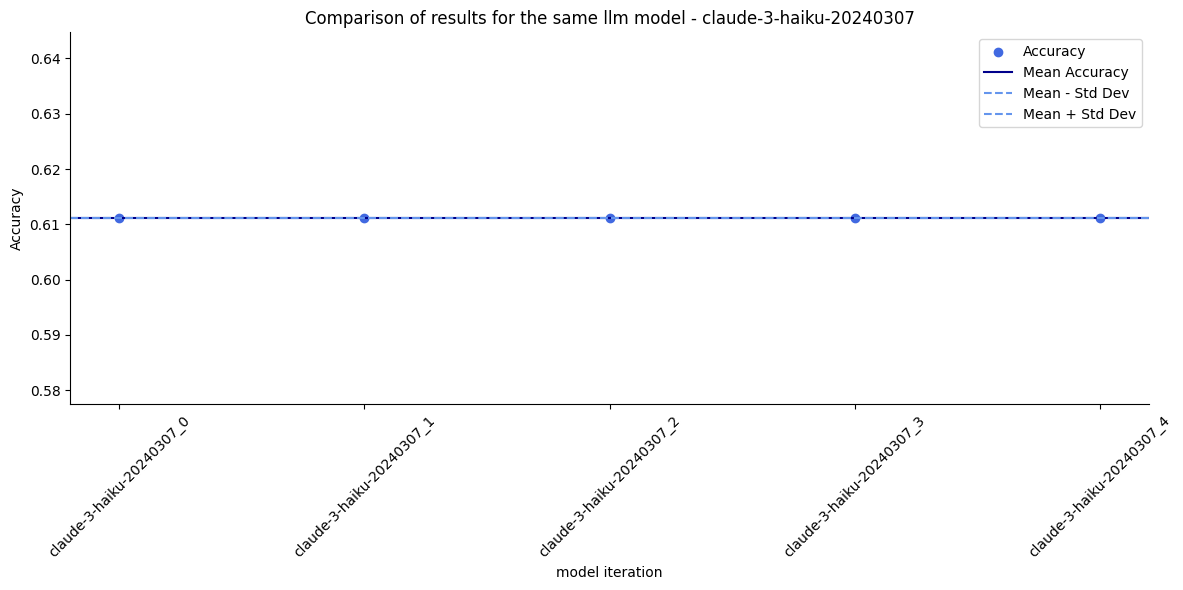

In [62]:
graph_scatter_plot(df = df_result_claude_haiku_3,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - claude-3-haiku-20240307",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

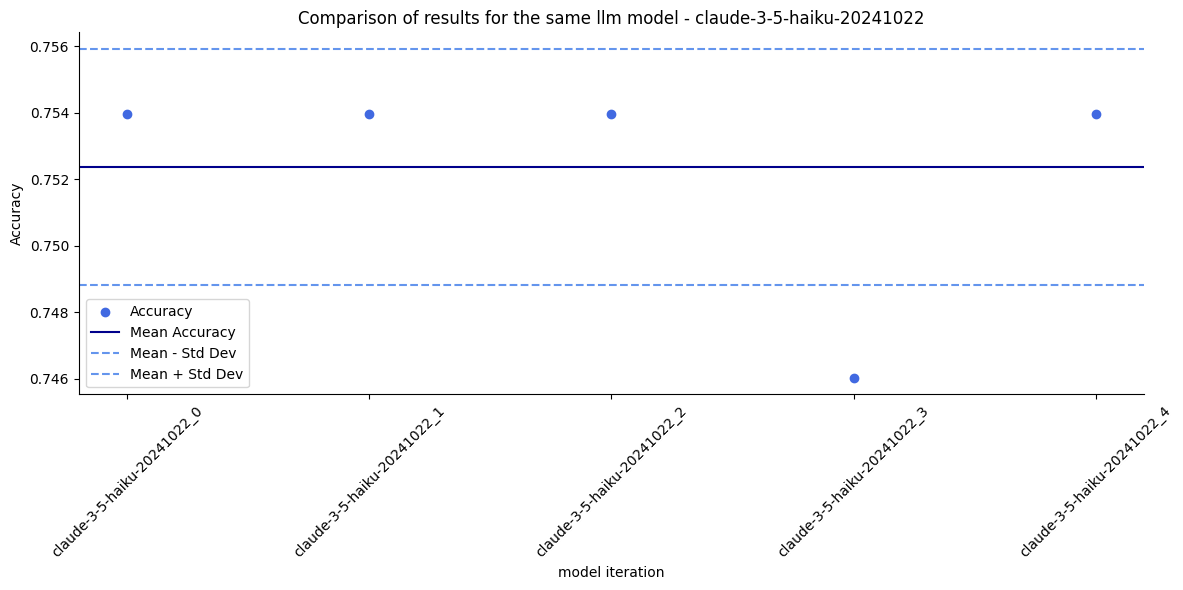

In [63]:
graph_scatter_plot(df = df_result_claude_haiku_35,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - claude-3-5-haiku-20241022",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

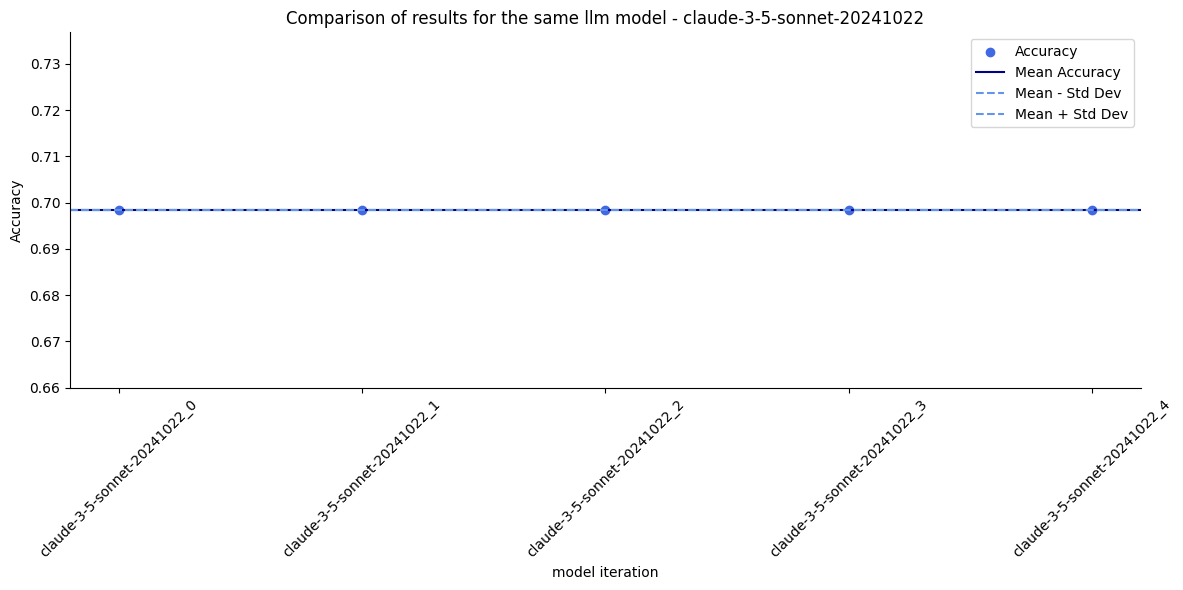

In [64]:
graph_scatter_plot(df = df_result_claude_sonnet_35,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - claude-3-5-sonnet-20241022",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

Nota-se que para modelos mais avançados a variabilidade é menor, indicando estabilização mais rápida.

In [65]:
### Grava os resultados finais
df_result_claude_haiku_3.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_claude_haiku_3_final_slr1_v2.xlsx", index=False)
df_result_claude_haiku_3.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_claude_haiku_3_final_slr1_v2.csv", encoding='utf-8', index=False)

df_result_claude_haiku_35.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_claude_haiku_35_slr1_v2.xlsx", index=False)
df_result_claude_haiku_35.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_claude_haiku_35_slr1_v2.csv", encoding='utf-8', index=False)

df_result_claude_sonnet_35.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_claude_sonnet_35_slr1_v2.xlsx", index=False)
df_result_claude_sonnet_35.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_claude_sonnet_35_slr1_v2.csv", encoding='utf-8', index=False)

### Comparativo Geral

In [66]:
df_result_claude_haiku_3["iteration"] = df_result_claude_haiku_3["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_claude_haiku_3["model"] = "claude-3-haiku-20240307"

df_result_claude_haiku_35["iteration"] = df_result_claude_haiku_35["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_claude_haiku_35["model"] = "claude-3-5-haiku-20241022"

df_result_claude_sonnet_35["iteration"] = df_result_claude_sonnet_35["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_claude_sonnet_35["model"] = "claude-3-5-sonnet-20241022"

In [67]:
# concatena os dataframes
df_results = pd.concat([df_result_claude_haiku_3, 
                        df_result_claude_haiku_35, 
                        df_result_claude_sonnet_35], ignore_index=True)
df_results.head(2)

,Model_Iteration,Accuracy,iteration,model
0,claude-3-haiku-20240307_0,0.611111,0,claude-3-haiku-20240307
1,claude-3-haiku-20240307_1,0.611111,1,claude-3-haiku-20240307


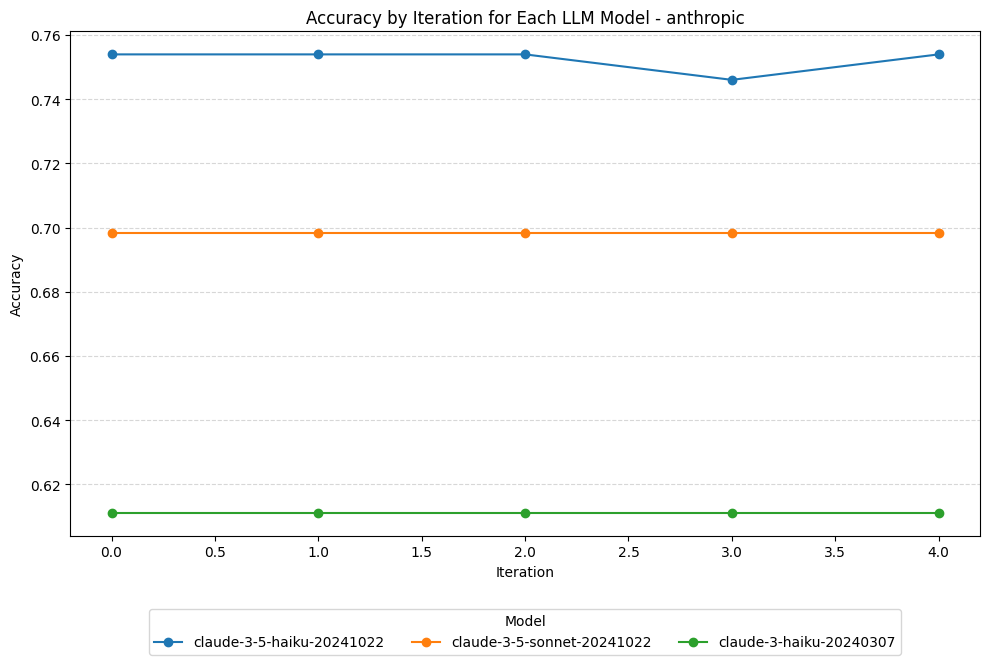

In [68]:
plt.figure(figsize=(10, 6))
for model_name, group in df_results.groupby("model"):
    plt.plot(group["iteration"], group["Accuracy"], marker='o', label=model_name)

plt.title("Accuracy by Iteration for Each LLM Model - anthropic")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(title="Model", loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)
plt.show()
